In [1]:
import os

def load_agent_positions(save_dir: str, start_index: int, last_index: int):
    """Load agent positions saved as `{index}_agent_positions.npz`.

    Returns a dict with keys `agent_xy` (concatenated numpy array) and `update_idx`.
    """
    import numpy as _np
    import re

    files = []
    for name in os.listdir(save_dir):
        match = re.match(r"^(\d+)_agent_positions\.npz$", name)
        if match:
            files.append((int(match.group(1)), os.path.join(save_dir, name)))

    if not files:
        raise FileNotFoundError(f"No '*_agent_positions.npz' files found in {save_dir}")

    files.sort(key=lambda x: x[0])
    candidates = files[start_index:last_index]

    if not candidates:
        raise FileNotFoundError("No candidate files available")

    agent_xy_list = []
    update_indices = []

    for selected_idx, fname in candidates:
        with _np.load(fname) as data:
            agent_xy_list.append(data["agent_xy"].copy())
            update_indices.append(int(data["update_idx"]) if "update_idx" in data else selected_idx)

    agent_xy = _np.concatenate(agent_xy_list, axis=0)

    return {"agent_xy": agent_xy, "update_idx": update_indices}


import imageio.v2 as imageio


def _frames_to_mp4(frames, output_path, duration: float = 0.5):
    """Write RGB frames to an mp4 file via imageio/ffmpeg.

    If frame sizes differ, resize all frames to match the last image.
    """
    import numpy as _np
    from PIL import Image

    fps = 1.0 / duration if duration and duration > 0 else 2.0
    target_h, target_w = frames[-1].shape[:2]

    rgb_frames = []
    for img in frames:
        if img.ndim == 3 and img.shape[-1] == 4:
            img = img[..., :3]
        if img.shape[0] != target_h or img.shape[1] != target_w:
            pil_img = Image.fromarray(img)
            pil_img = pil_img.resize((target_w, target_h), Image.Resampling.LANCZOS)
            img = _np.asarray(pil_img)
        rgb_frames.append(img)
    imageio.mimsave(output_path, rgb_frames, fps=fps)


def _checkpoint_color(uidx, step_min, step_max, cmap):
    import numpy as _np

    if step_max > step_min:
        t = float((uidx - step_min) / (step_max - step_min))
    else:
        t = 0.0
    return _np.asarray(cmap(t), dtype=_np.float32)


def _rasterize_checkpoint_layer(xy, color_rgba, xlim, ylim, size, point_alpha=0.1):
    import numpy as _np

    width, height = size
    layer = _np.zeros((height, width, 4), dtype=_np.float32)
    if xy.shape[0] == 0:
        return layer

    x_span = xlim[1] - xlim[0]
    y_span = ylim[1] - ylim[0]
    if x_span <= 0 or y_span <= 0:
        return layer

    cols = _np.clip(
        ((xy[:, 0] - xlim[0]) / x_span * (width - 1)).astype(_np.int32),
        0,
        width - 1,
    )
    rows = _np.clip(
        ((ylim[1] - xy[:, 1]) / y_span * (height - 1)).astype(_np.int32),
        0,
        height - 1,
    )

    r, g, b, _ = color_rgba
    np_add = _np.add.at
    np_add(layer[..., 0], (rows, cols), r * point_alpha)
    np_add(layer[..., 1], (rows, cols), g * point_alpha)
    np_add(layer[..., 2], (rows, cols), b * point_alpha)
    np_add(layer[..., 3], (rows, cols), point_alpha)
    return layer


def _alpha_over(dst, src):
    import numpy as _np

    src_a = src[..., 3:4]
    dst_a = dst[..., 3:4]
    out_a = src_a + dst_a * (1.0 - src_a)
    out_rgb = _np.zeros_like(dst[..., :3])
    mask = out_a[..., 0] > 0
    out_rgb[mask] = (
        src[..., :3][mask] * src_a[mask]
        + dst[..., :3][mask] * dst_a[mask] * (1.0 - src_a[mask])
    ) / out_a[mask]
    result = _np.zeros_like(dst)
    result[..., :3] = out_rgb
    result[..., 3:4] = out_a
    return result


def _composite_layers(layers):
    import numpy as _np

    canvas = _np.zeros(layers[0].shape, dtype=_np.float32)
    for layer in layers:
        canvas = _alpha_over(canvas, layer)
    return canvas


def _layer_frame_to_rgb(frame_rgba):
    import numpy as _np

    alpha = frame_rgba[..., 3:4]
    rgb = frame_rgba[..., :3] * alpha + (1.0 - alpha)
    return _np.clip(rgb * 255.0, 0, 255).astype(_np.uint8)


def _add_frame_title(rgb_frame, title):
    import numpy as _np
    from PIL import Image, ImageDraw

    img = Image.fromarray(rgb_frame)
    draw = ImageDraw.Draw(img)
    draw.text((8, 8), title, fill=(0, 0, 0))
    return _np.asarray(img)


def load_agent_positions_visuals(
    save_dir: str,
    start_index: int,
    last_index: int,
    output_path=None,
    duration: float = 0.5,
    render_mode: str = "layers",
    max_points_per_checkpoint=None,
    image_size=(800, 800),
    dpi: int = 150,
    store_frames: bool = True,
):
    """Load agent position checkpoints and create a cumulative scatter MP4 animation.

    Expects files named `{update_idx}_agent_positions.npz`, sorted by update index.
    Selects the slice `[start_index:last_index]` of that sorted list. Each frame
    cumulatively adds the next checkpoint's points so early training steps appear
    first and the scatter trail grows over time.

    By default uses fast checkpoint layer compositing. Set `render_mode='scatter'`
    to use the slower matplotlib scatter fallback.

    Returns a dict with keys `video_path`, `update_idx`, and `frames`.
    """
    import io
    import re

    import matplotlib
    import numpy as _np

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    files = []
    for name in os.listdir(save_dir):
        match = re.match(r"^(\d+)_agent_positions\.npz$", name)
        if match:
            files.append((int(match.group(1)), os.path.join(save_dir, name)))

    if not files:
        raise FileNotFoundError(f"No '*_agent_positions.npz' files found in {save_dir}")

    files.sort(key=lambda x: x[0])
    candidates = files[start_index:last_index]

    if not candidates:
        raise FileNotFoundError("No candidate files available")

    checkpoints = []
    update_indices = []
    for selected_idx, fname in candidates:
        with _np.load(fname) as data:
            xy = data["agent_xy"].copy().reshape(-1, 2)
            uidx = int(data["update_idx"]) if "update_idx" in data else selected_idx
            if (
                max_points_per_checkpoint is not None
                and xy.shape[0] > max_points_per_checkpoint
            ):
                pick = _np.random.choice(
                    xy.shape[0], int(max_points_per_checkpoint), replace=False
                )
                xy = xy[pick]
            checkpoints.append((xy, uidx))
            update_indices.append(uidx)

    all_xy = _np.concatenate([xy for xy, _ in checkpoints], axis=0)
    if all_xy.shape[0] == 0:
        raise ValueError("Need at least one trajectory point to plot.")

    padding = 0.05
    x_min, x_max = float(all_xy[:, 0].min()), float(all_xy[:, 0].max())
    y_min, y_max = float(all_xy[:, 1].min()), float(all_xy[:, 1].max())
    x_pad = (x_max - x_min) * padding if x_max > x_min else 1.0
    y_pad = (y_max - y_min) * padding if y_max > y_min else 1.0
    xlim = (x_min - x_pad, x_max + x_pad)
    ylim = (y_min - y_pad, y_max + y_pad)

    step_min = float(min(uidx for _, uidx in checkpoints))
    step_max = float(max(uidx for _, uidx in checkpoints))

    cmap = plt.get_cmap("Blues")
    mp4_frames = []
    returned_frames = [] if store_frames else None

    if render_mode == "layers":
        width, height = image_size
        canvas = _np.zeros((height, width, 4), dtype=_np.float32)
        for xy, uidx in checkpoints:
            color = _checkpoint_color(uidx, step_min, step_max, cmap)
            layer = _rasterize_checkpoint_layer(
                xy, color, xlim, ylim, (width, height), point_alpha=0.1
            )
            canvas = _alpha_over(canvas, layer)
            rgb = _layer_frame_to_rgb(canvas)
            rgb = _add_frame_title(rgb, f"Agent Positions (update {uidx})")
            mp4_frames.append(rgb)
            if store_frames:
                returned_frames.append(rgb)
    elif render_mode == "scatter":
        cumulative_xy = []
        cumulative_steps = []
        for xy, uidx in checkpoints:
            cumulative_xy.append(xy)
            cumulative_steps.append(_np.full(xy.shape[0], uidx, dtype=_np.float64))

            xy_cat = _np.concatenate(cumulative_xy, axis=0)
            steps_cat = _np.concatenate(cumulative_steps, axis=0)

            if step_max > step_min:
                color_values = (steps_cat - step_min) / (step_max - step_min)
            else:
                color_values = _np.zeros_like(steps_cat, dtype=_np.float64)

            fig, ax = plt.subplots(figsize=(6.5, 6))
            ax.scatter(
                xy_cat[:, 0],
                xy_cat[:, 1],
                c=cmap(color_values),
                s=1,
                alpha=0.1,
                linewidths=0,
            )
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)
            ax.set_title(f"Agent Positions (update {uidx})")
            ax.axis("off")

            buf = io.BytesIO()
            fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
            plt.close(fig)
            buf.seek(0)
            rgb = imageio.imread(buf)
            if rgb.ndim == 3 and rgb.shape[-1] == 4:
                rgb = rgb[..., :3]
            mp4_frames.append(rgb)
            if store_frames:
                returned_frames.append(rgb)
    else:
        raise ValueError("render_mode must be 'layers' or 'scatter'")

    if output_path is None:
        output_path = os.path.join(
            save_dir, f"agent_positions_visuals_{start_index}_{last_index}.mp4"
        )

    _frames_to_mp4(mp4_frames, output_path, duration=duration)
    print(f"Saved agent positions visuals to {output_path}")

    return {
        "video_path": output_path,
        "update_idx": update_indices,
        "frames": returned_frames if store_frames else [],
    }


def load_teacher_goal_visuals(
    save_dir: str,
    start_index: int,
    last_index: int,
    output_path=None,
    duration: float = 0.5,
):
    """Load teacher goal count images and create an MP4 animation.

    Expects files named `..._teacher_goal_counts_{update_idx}.png`, sorted by
    update index. Selects the slice `[start_index:last_index]` of that sorted
    list and writes an animation with imageio.

    Returns a dict with keys `video_path`, `update_idx`, and `frames`.
    """
    import re

    files = []
    # print(save_dir)
    for name in os.listdir(save_dir):
        # print(name)
        # purejaxrl_ppo_brax_ant_u_maze_single_goal_teacher_goal_counts_0.png
        match = re.match(
            r"^purejaxrl_ppo_brax_ant_u_maze_single_goal_teacher_goal_counts_(\d+)\.png$",
            name,
        )
        if match:
            files.append((int(match.group(1)), os.path.join(save_dir, name)))

    if not files:
        raise FileNotFoundError(
            f"No '*_teacher_goal_counts_*.png' files found in {save_dir}"
        )

    files.sort(key=lambda x: x[0])
    candidates = files[start_index:last_index]

    if not candidates:
        raise FileNotFoundError("No candidate files available")

    update_indices = []
    frames = []
    for selected_idx, fname in candidates:
        frames.append(imageio.imread(fname))
        update_indices.append(selected_idx)

    if output_path is None:
        output_path = os.path.join(
            save_dir, f"teacher_goal_visuals_{start_index}_{last_index}.mp4"
        )

    _frames_to_mp4(frames, output_path, duration=duration)
    print(f"Saved teacher goal visuals to {output_path}")

    return {
        "video_path": output_path,
        "update_idx": update_indices,
        "frames": frames,
    }


def load_empowerment_visuals(
    save_dir: str,
    start_index: int,
    last_index: int,
    output_path=None,
    duration: float = 0.5,
):
    """Load teacher empowerment images and create an MP4 animation.

    Expects files named `..._teacher_empowerment_grid_{update_idx}.png`, sorted
    by update index. Selects the slice `[start_index:last_index]` of that sorted
    list and writes an animation with imageio.

    Returns a dict with keys `video_path`, `update_idx`, and `frames`.
    """
    import re

    files = []
    for name in os.listdir(save_dir):
        # purejaxrl_ppo_brax_ant_u_maze_single_goal_teacher_empowerment_grid_0.png
        match = re.match(
            r"^purejaxrl_ppo_brax_ant_u_maze_single_goal_teacher_empowerment_grid_(\d+)\.png$",
            name,
        )
        if match:
            files.append((int(match.group(1)), os.path.join(save_dir, name)))

    if not files:
        raise FileNotFoundError(
            f"No '*_teacher_empowerment_grid_*.png' files found in {save_dir}"
        )

    files.sort(key=lambda x: x[0])
    candidates = files[start_index:last_index]

    if not candidates:
        raise FileNotFoundError("No candidate files available")

    update_indices = []
    frames = []
    for selected_idx, fname in candidates:
        frames.append(imageio.imread(fname))
        update_indices.append(selected_idx)

    if output_path is None:
        output_path = os.path.join(
            save_dir, f"teacher_empowerment_visuals_{start_index}_{last_index}.mp4"
        )

    _frames_to_mp4(frames, output_path, duration=duration)
    print(f"Saved teacher empowerment visuals to {output_path}")

    return {
        "video_path": output_path,
        "update_idx": update_indices,
        "frames": frames,
    }

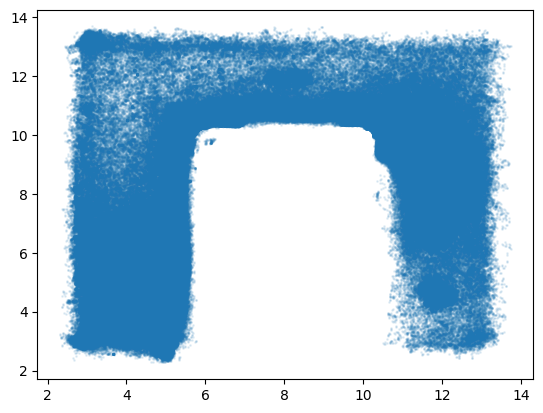

In [2]:
exp_path = "/network/scratch/f/faisal.mohamed/purejaxrl_simple_teachers/individual_754568460"
positions_path = os.path.join(exp_path, "agent_positions")
goal_counts_path = os.path.join(exp_path, "teacher_goal_visuals")
empowerment_path = os.path.join(exp_path, "teacher_empowerment_visuals")
start = 0
end = -1
output = load_agent_positions(positions_path, start, end)
xy = output["agent_xy"]
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(xy[:, 0], xy[:, 1], s=1, alpha=0.1)
# plt.axis("off")
# plt.show()

In [3]:
output = load_teacher_goal_visuals(goal_counts_path, start, end, duration=1)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (915, 817) to (928, 832) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved teacher goal visuals to /network/scratch/f/faisal.mohamed/purejaxrl_simple_teachers/individual_754568460/teacher_goal_visuals/teacher_goal_visuals_0_-1.mp4


In [ ]:
output = load_empowerment_visuals(empowerment_path, start, end, duration=0.25)

In [6]:
end =-1
output = load_agent_positions_visuals(positions_path, start, end, duration=1, render_mode="layers")

Saved agent positions visuals to /network/scratch/f/faisal.mohamed/purejaxrl_simple_teachers/individual_754568460/agent_positions/agent_positions_visuals_0_-1.mp4
